Se inicia el analisis exploratorio de los datos, con el objetivo de entender la estructura y las características de los datos, identificar patrones y relaciones entre las variables, y detectar posibles problemas o anomalías en los datos. Este proceso es fundamental para tomar decisiones informadas sobre cómo proceder con el análisis y la modelización de los datos.

In [2]:
# Implementacion de las librerias y la carga de los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de los datos
df = pd.read_csv('dataset_chile_cancer_piel.csv')

print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

El dataset tiene 1000 filas y 27 columnas.


,Edad (años),Sexo,Peso (kg),Estatura (cm),IMC (calculado),Tabaquismo,Años-paquete,Consumo de alcohol,Inmunosupresión,Exposición solar crónica,...,Costra persistente,Bordes elevados/irregulares,Endurecimiento,Supuración,Cambio reciente de tamaño/color,Sutura o manipulación previa,Respuesta a antibióticos previos,Pérdida de peso involuntaria,Fiebre persistente,Fatiga
0,65,Hombre,64.9,170.7,22.3,No,0.0,Frecuente,Sí,No,...,Sí,No,Sí,No,Sí,No,Mala,No,No,No
1,47,Hombre,80.9,177.1,25.8,Sí,37.1,Ocasional,No,No,...,Sí,No,Sí,Sí,No,No,Parcial,No,Sí,No
2,80,Mujer,70.9,152.7,30.4,Sí,36.8,Ocasional,Sí,No,...,No,Sí,Sí,No,Sí,No,Mala,Sí,No,No
3,63,Mujer,73.7,154.6,30.8,Sí,21.3,Frecuente,No,Sí,...,No,No,No,Sí,Sí,Sí,Mala,No,No,No
4,60,Hombre,62.6,163.5,23.4,Sí,22.5,Frecuente,No,Sí,...,No,Sí,Sí,No,Sí,No,Nula,No,Sí,No


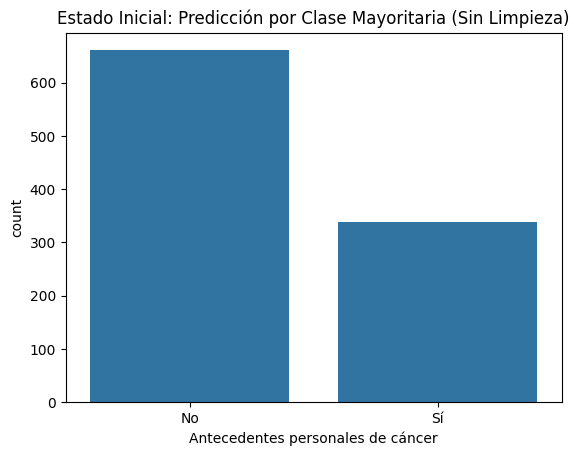

In [3]:
# Así se ve la "base" de tu predicción antes de procesar nada
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Antecedentes personales de cáncer', data=df)
plt.title('Estado Inicial: Predicción por Clase Mayoritaria (Sin Limpieza)')
plt.show()

# 2 inspeccion de los datos y la limpieza inicial de los datos:
  * identificar los valores que se encuentren nulos para asegurar la calidad de la tecnica de modelado, y tomar decisiones sobre cómo manejar estos valores (por ejemplo, eliminarlos, imputarlos o dejarlos como están).
  * verificar que valores como edad o IMC sean numeros positivos, y que el sexo solo tenga dos categorias (masculino o femenino).

In [5]:
print(df.info())
print(df.describe())
print("Valores faltantes por columnas:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Edad (años)                        1000 non-null   int64  
 1   Sexo                               1000 non-null   str    
 2   Peso (kg)                          1000 non-null   float64
 3   Estatura (cm)                      1000 non-null   float64
 4   IMC (calculado)                    1000 non-null   float64
 5   Tabaquismo                         1000 non-null   str    
 6   Años-paquete                       1000 non-null   float64
 7   Consumo de alcohol                 1000 non-null   str    
 8   Inmunosupresión                    1000 non-null   str    
 9   Exposición solar crónica           1000 non-null   str    
 10  Antecedentes personales de cáncer  1000 non-null   str    
 11  Cáncer familiar 1er grado (tipo)   1000 non-null   str    
 12  Loca

In [10]:
print("Distribución de la variable objetivo antes de la limpieza:")
print(df['Antecedentes personales de cáncer'].value_counts())
print("")
print("Porcentaje de cada clase:")
print(df['Antecedentes personales de cáncer'].value_counts(normalize=True) * 100)
print("")
print("Número de valores nulos en cada columna:")
print(df.isnull().sum())


Distribución de la variable objetivo antes de la limpieza:
Antecedentes personales de cáncer
No    661
Sí    339
Name: count, dtype: int64

Porcentaje de cada clase:
Antecedentes personales de cáncer
No    66.1
Sí    33.9
Name: proportion, dtype: float64

Número de valores nulos en cada columna:
Edad (años)                          0
Sexo                                 0
Peso (kg)                            0
Estatura (cm)                        0
IMC (calculado)                      0
Tabaquismo                           0
Años-paquete                         0
Consumo de alcohol                   0
Inmunosupresión                      0
Exposición solar crónica             0
Antecedentes personales de cáncer    0
Cáncer familiar 1er grado (tipo)     0
Localización de la lesión            0
Tiempo de evolución                  0
Tamaño máximo (cm)                   0
Dolor                                0
Ulceración o sangrado espontáneo     0
Costra persistente                   0
B

3. Visualizacion de variables:
    * se analisa la distribucion de las variables que podrian tener mayor poder de discriminante tales como:
        - edad
        - IMC
        - antecedentes familiares de cancer
        - antecedentes personales de cancer

/tmp/ipykernel_6486/3838797795.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Antecedentes personales de cáncer', y='IMC (calculado)',


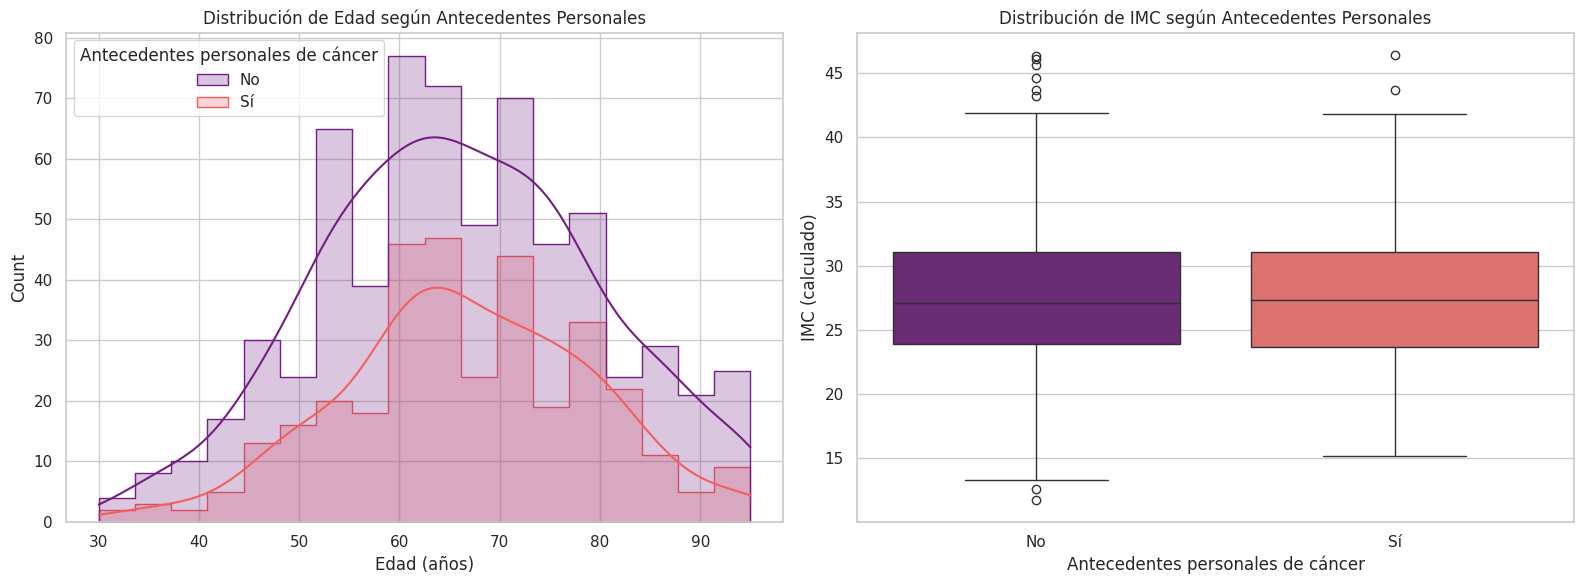

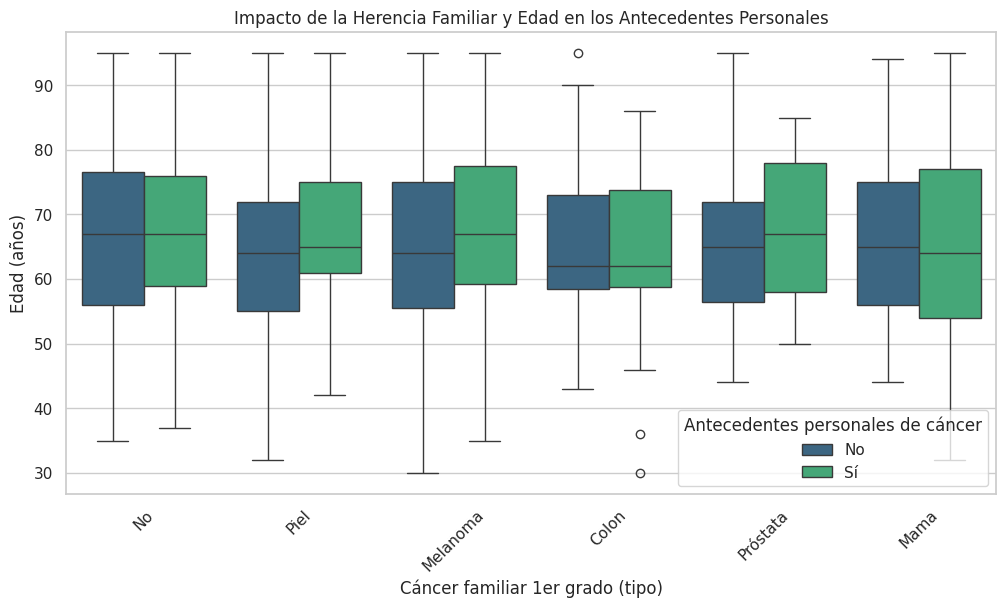

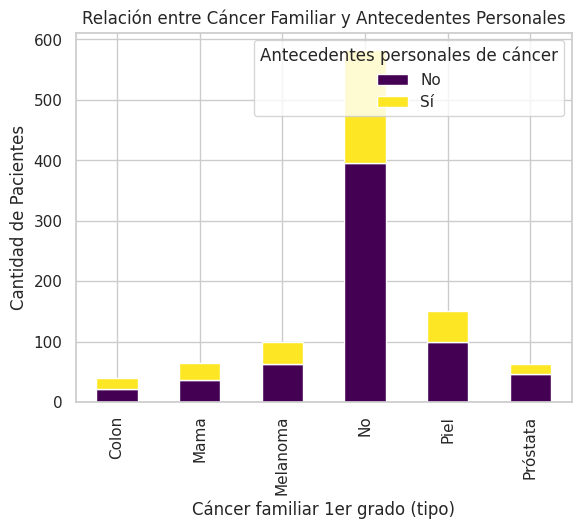

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo para que se vea profesional
sns.set_theme(style="whitegrid")

# 1. RELACIÓN DE EDAD E IMC CON ANTECEDENTES PERSONALES (Tu variable objetivo)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de Edad segmentado por Antecedentes Personales
sns.histplot(data=df, x='Edad (años)', hue='Antecedentes personales de cáncer', 
             kde=True, element="step", ax=axes[0], palette='magma')
axes[0].set_title('Distribución de Edad según Antecedentes Personales')

# Boxplot de IMC segmentado por Antecedentes Personales
sns.boxplot(data=df, x='Antecedentes personales de cáncer', y='IMC (calculado)', 
            ax=axes[1], palette='magma')
axes[1].set_title('Distribución de IMC según Antecedentes Personales')

plt.tight_layout()
plt.show()

# 2. RELACIÓN CON ANTECEDENTES FAMILIARES
# Nota: "Cáncer familiar 1er grado (tipo)" tiene categorías como 'Piel', 'Colon', 'No'.
plt.figure(figsize=(12, 6))

# Boxplot de Edad según el tipo de Cáncer Familiar
sns.boxplot(data=df, x='Cáncer familiar 1er grado (tipo)', y='Edad (años)', 
            hue='Antecedentes personales de cáncer', palette='viridis')
plt.title('Impacto de la Herencia Familiar y Edad en los Antecedentes Personales')
plt.xticks(rotation=45)
plt.show()

# 3. ANÁLISIS DE CORRELACIÓN CATEGÓRICA (Frecuencias)
# Ver si tener antecedentes familiares se relaciona con tener antecedentes personales
pd.crosstab(df['Cáncer familiar 1er grado (tipo)'], 
            df['Antecedentes personales de cáncer']).plot(kind='bar', stacked=True, color=['#440154', '#fde725'])
plt.title('Relación entre Cáncer Familiar y Antecedentes Personales')
plt.ylabel('Cantidad de Pacientes')
plt.show()

4. Analisis bivariado:
    * se analisa la relacion entre las variables predictoras y la variable objetivo, utilizando tecnicas como tablas de contingencia, graficos de dispersión, o pruebas de correlacion, para identificar posibles asociaciones o patrones que puedan ser relevantes para el modelado supervisado.
    Deteccion de patrones y relaciones entre las variables:
    * se analisa la relacion entre las variables predictoras y la variable objetivo, utilizando tecnicas como tablas de contingencia, graficos de dispersión, o pruebas de correlacion, para identificar posibles asociaciones o patrones que puedan ser relevantes para el modelado supervisado.

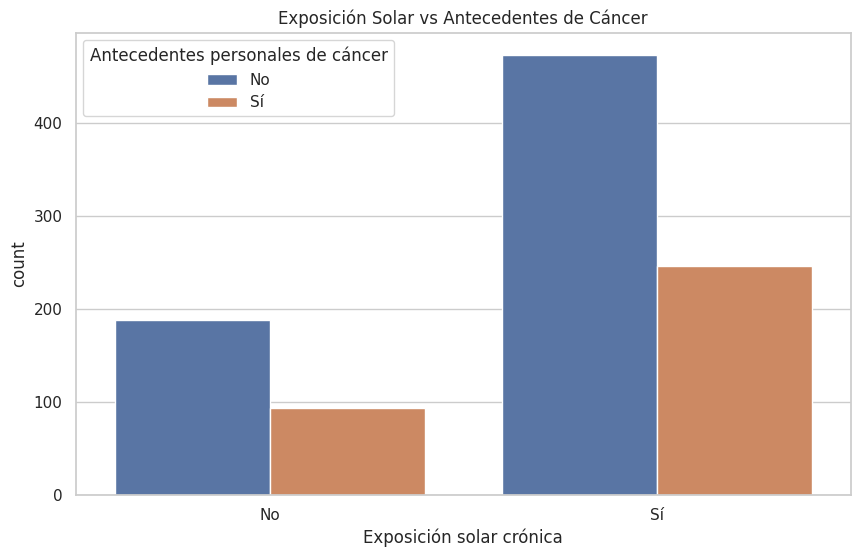

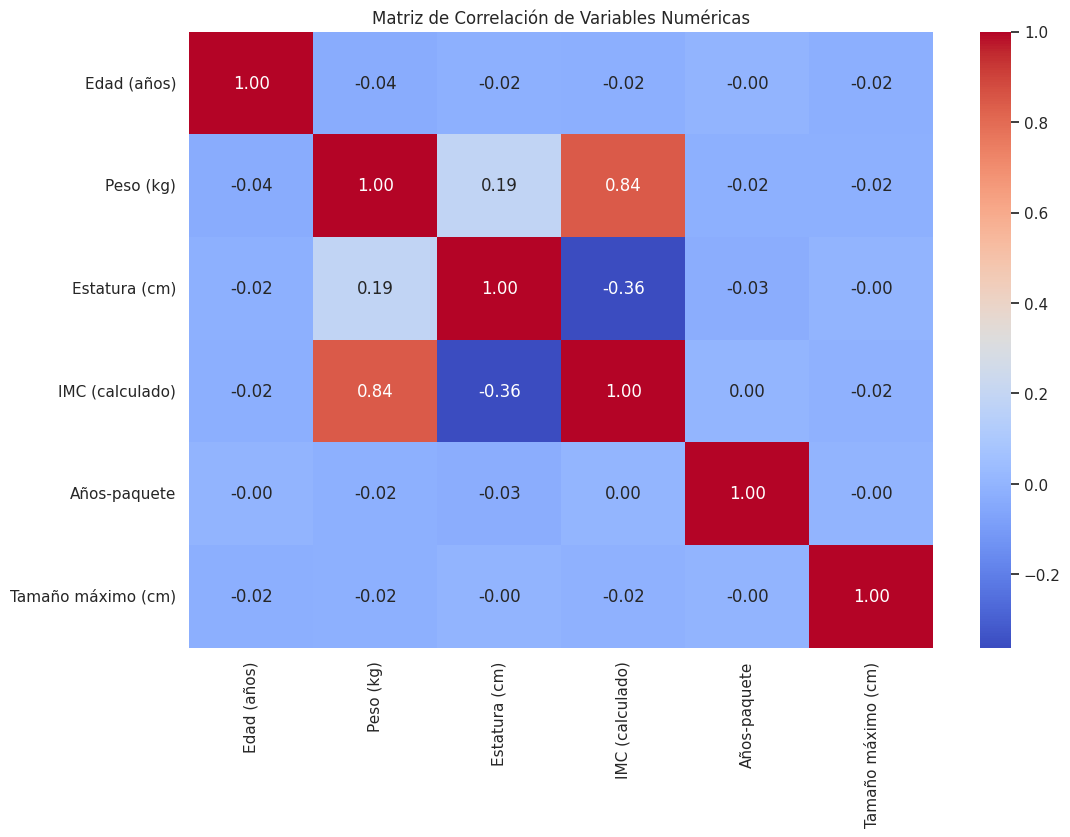

In [12]:
# Relación entre Exposición Solar y Antecedentes de Cáncer
plt.figure(figsize=(10, 6))
sns.countplot(x='Exposición solar crónica', hue='Antecedentes personales de cáncer', data=df)
plt.title('Exposición Solar vs Antecedentes de Cáncer')
plt.show()

# Matriz de correlación (solo variables numéricas)
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()